# Explainability

This notebook follows the project explainability plan:
- Feature-based explanations for the baseline model
- XAI techniques for the Transformer model (SHAP and Integrated Gradients)

## 1. Setup

I import libraries and set project paths. The notebook is intentionally lightweight and uses only a few examples for Transformer XAI, to keep runtime manageable.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython.display import display

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

try:
    import shap
    shap.initjs()
except ImportError:
    shap = None

try:
    from captum.attr import IntegratedGradients
except ImportError:
    IntegratedGradients = None

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data import load_dreaddit_dataframe

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"SHAP available: {shap is not None}")
print(f"Captum available: {IntegratedGradients is not None}")


Device: cpu
SHAP available: True
Captum available: True


## 2. Load Data, Splits, and Trained Transformer

I load the Dreaddit dataset, test split indices, and the latest available DistilBERT checkpoint generated during training.

In [2]:
df = load_dreaddit_dataframe(prefer_local_raw=True)

train_idx_path = ROOT / "data" / "train_idx.npy"
test_idx_path = ROOT / "data" / "test_idx.npy"

if not train_idx_path.exists() or not test_idx_path.exists():
    raise FileNotFoundError("Expected split indices in data/train_idx.npy and data/test_idx.npy")

train_idx = np.load(train_idx_path)
test_idx = np.load(test_idx_path)

test_df = df.loc[test_idx, ["text", "label"]].copy()
test_df["text"] = test_df["text"].astype(str)
test_df["label"] = test_df["label"].astype(int)

ckpt_root = ROOT / "results" / "transformer" / "distilbert"
checkpoint_candidates = sorted(
    [p for p in ckpt_root.glob("checkpoint-*") if p.is_dir()],
    key=lambda p: int(p.name.split("-")[-1]),
)

if checkpoint_candidates:
    MODEL_PATH = str(ROOT / "results" / "transformer" / "distilbert" / "best_model")
else:
    print("[WARNING] No fine-tuned checkpoints found.")
    print("[WARNING] Using base model instead of fine-tuned weights.")
    MODEL_PATH = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(device)
model.eval()

print(f"Model path: {MODEL_PATH}")
print(f"Test size: {len(test_df)}")
test_df.head()


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model path: /Users/jacopoamoretti/Desktop/-Universita Bologna-/2025_2026/AI in Industry/Progetto/dreaddit-stress-nlp/results/transformer/distilbert/best_model
Test size: 143


,text,label
685,-What are you gonna do with that strange looki...,0
532,But what should I say? Part of me wants to tel...,1
268,Hey guys I have PTSD from years of emotional a...,1
507,"We had 2 classes together, so we spent a few h...",1
465,It's really just standard-issue big corporatio...,1


The setup above ensures we explain the same model and split used for evaluation.

## 3. Baseline Explainability (Feature-Based)

For the baseline logistic regression, explanations are direct: coefficient sign and magnitude indicate each feature contribution.

In [3]:
coef_path = ROOT / "results" / "baseline" / "logreg_coefficients.csv"
if not coef_path.exists():
    raise FileNotFoundError(f"Missing coefficients file: {coef_path}")

coef_df = pd.read_csv(coef_path)
coef_df = coef_df.sort_values("coefficient", ascending=False).reset_index(drop=True)
coef_df.head(10)


,feature,coefficient
0,lex_liwc_i,0.614177
1,lex_liwc_WC,0.489971
2,lex_liwc_negemo,0.451971
3,lex_liwc_anx,0.368407
4,lex_dal_avg_imagery,0.208697
5,lex_liwc_negate,0.193093
6,lex_dal_avg_activation,0.051817
7,lex_liwc_sad,0.019655
8,lex_liwc_Authentic,-0.036775
9,syntax_fk_grade,-0.071196


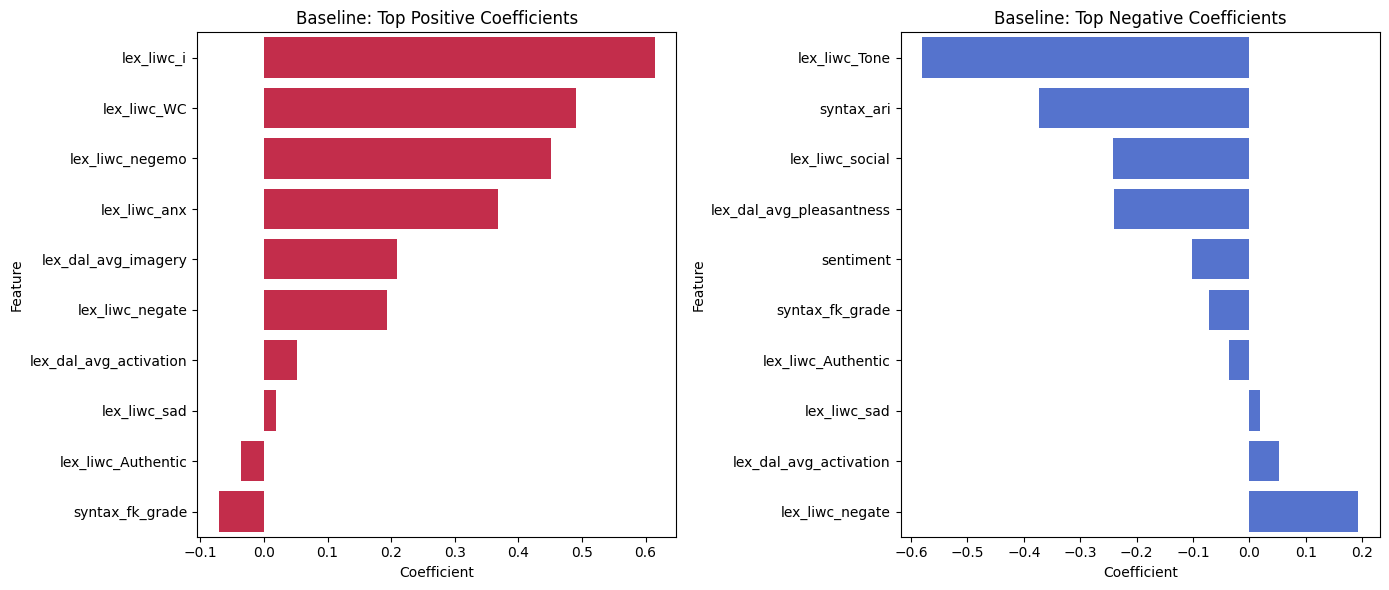

In [4]:
top_n = 10
top_pos = coef_df.nlargest(top_n, "coefficient")
top_neg = coef_df.nsmallest(top_n, "coefficient")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=top_pos, y="feature", x="coefficient", ax=axes[0], color="crimson")
axes[0].set_title("Baseline: Top Positive Coefficients")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("Feature")

sns.barplot(data=top_neg, y="feature", x="coefficient", ax=axes[1], color="royalblue")
axes[1].set_title("Baseline: Top Negative Coefficients")
axes[1].set_xlabel("Coefficient")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()


The analysis of the logistic regression coefficients highlights clear and interpretable patterns in stress-related language.

The strongest positive contributors to stress predictions are first-person singular pronouns (lex_liwc_i), text length (lex_liwc_WC), and negative emotional language (lex_liwc_negemo, lex_liwc_anx). This suggests that stress-related posts tend to be self-focused, emotionally negative, and often longer, consistent with patterns of emotional disclosure and rumination.

Interestingly, higher imagery scores (lex_dal_avg_imagery) also contribute positively, indicating that stress-related posts frequently include concrete, detailed narratives of personal experiences.

Conversely, features associated with positive emotional tone (lex_liwc_Tone, lex_dal_avg_pleasantness, sentiment), social references (lex_liwc_social), and higher readability (syntax_ari, syntax_fk_grade) are negatively associated with stress. This suggests that non-stress posts tend to be more positive, socially oriented, and linguistically structured.

Overall, these results confirm that affective and psycholinguistic features capture meaningful signals of stress expression, while remaining interpretable and consistent with the exploratory analysis.


## 4. Transformer Explainability with SHAP

SHAP gives local token-level explanations for individual predictions by estimating each token contribution to model output.

In [5]:
# Prediction function: texts -> probabilities [P(non_stress), P(stress)]

def predict_fn(texts):
    # Tokenize a batch of texts
    enc = tokenizer(
        [str(t) for t in texts],
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt",
    )

    # Move to same device as model
    device = next(model.parameters()).device
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        outputs = model(
            input_ids=enc["input_ids"],
            attention_mask=enc["attention_mask"])
        logits = outputs.logits

    return torch.softmax(logits, dim=1).detach().cpu().numpy()

$$
\phi_i(x) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!(|N| - |S| - 1)!}{|N|!} \left[ f(x_{S \cup \{i\}}) - f(x_S) \right]
$$

Where $\phi_i(x)$ represents the contribution of feature $i$ to the prediction, computed as the weighted average of its marginal contributions across all possible subsets of features.

In [6]:
# SHAP explainer (text masker)
masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_fn, masker, output_names=["non_stress", "stress"])

# Pick a few test examples and explain
shap_examples = test_df.sample(10, random_state=RANDOM_STATE)
shap_texts = shap_examples["text"].astype(str).tolist()
shap_values = explainer(shap_texts)
print("Computed SHAP for", len(shap_texts), "examples!")

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  10%|█         | 1/10 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  30%|███       | 3/10 [00:32<00:48,  6.94s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  40%|████      | 4/10 [00:45<00:57,  9.52s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 5/10 [00:59<00:54, 10.85s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  60%|██████    | 6/10 [01:12<00:46, 11.63s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  70%|███████   | 7/10 [01:25<00:36, 12.21s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  80%|████████  | 8/10 [01:39<00:25, 12.83s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  90%|█████████ | 9/10 [01:53<00:13, 13.13s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 10/10 [02:07<00:00, 13.31s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [02:20, 14.09s/it]                        

Computed SHAP for 10 examples!


The Text masker uses the tokenizer to hide or replace tokens in a tokenizer-aware way, so SHAP can perturb the input meaningfully. The explainer then repeatedly evaluates how the model output changes when different tokens are masked, and estimates an additive contribution for each token.

Here, predict_fn takes raw texts, tokenizes them, runs the Transformer, and returns class probabilities for non_stress and stress. Then explainer(shap_texts) computes token-level SHAP values for the sampled test posts. The result is an explanation object where each token receives a contribution score for each output class.

To better understand the behavior of the fine-tuned DistilBERT model, I analyze the token-level SHAP explanations for the first test example. Two explanations are generated: one for the non-stress class and one for the stress class.

In [7]:
# Explaination for non-stress class

if shap is not None and 'shap_values' in globals():
    # Explain first example for the non-stress class
    shap.plots.text(shap_values[0, :, 0])

Non-Stress Explanation:

The non-stress explanation shows that the post strongly decreases the non-stress output relative to its baseline. Many tokens in the post provide evidence against the non-stress class, pushing the final non-stress score far below the base value.

In [8]:
# Explaination for the stress class

if shap is not None and 'shap_values' in globals():
    # Interactive token contribution visualization for first example
    shap.plots.text(shap_values[0, :, 1])
else:
    print("SHAP values not available. Run previous SHAP cell first.")


Stress Explanation:

The second plot shows the SHAP explanation for the stress class. The base value (≈ 0.437) represents the model’s expected probability of predicting stress before seeing the input. After incorporating the token contributions from the text, the final prediction increases substantially to approximately 0.887.

Multiple tokens describing severe anxiety, panic attacks, and difficulties functioning in daily life contribute positively to the stress prediction. These tokens provide strong evidence that the post reflects psychological distress, which pushes the model’s prediction well above the baseline. The cumulative effect of these contributions leads the model to confidently classify the post as stress-related.

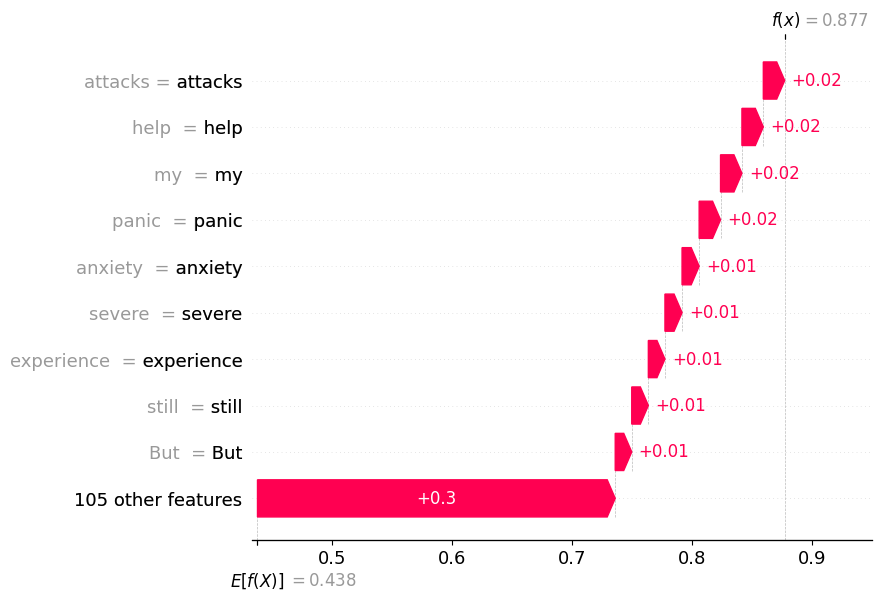

In [9]:
# Waterfall plot for an example post

shap.plots.waterfall(shap_values[0,:,1])

This waterfall plot provides a local explanation for one example classified as stress. It shows how the model output moves from the base value to the final prediction by adding the contribution of the most influential tokens.

In this case, the final stress score reaches approximately 0.887, which is substantially higher than the baseline output. The prediction is therefore pushed upward by several semantically meaningful tokens, including “panic”, “attacks”, “experience”, “my”, and “help”. These tokens are plausible indicators of psychological distress, because they reflect anxiety-related content, personal narrative style, and difficulty in functioning.

The bar labeled “105 other features” means that, beyond the few tokens shown explicitly, many additional tokens also contribute to the prediction. SHAP groups them together to keep the plot readable. So the decision is not driven by a single keyword, but by the cumulative effect of many contextual cues across the post.

Overall, this example suggests that the Transformer is relying on linguistically meaningful evidence when predicting stress, rather than on arbitrary artifacts.

## 5. Transformer Explainability with Integrated Gradients

To complement SHAP, I also apply **Integrated Gradients** as a gradient-based explainability method for the Transformer model.

While SHAP explains predictions by measuring how the output changes when parts of the input are perturbed or masked, Integrated Gradients works differently: it attributes importance by integrating the gradients of the model output along a continuous path from a baseline input to the actual input, capturing how each feature contributes as the input is gradually introduced.

In this notebook, I compute token-level attributions starting from the input embeddings. This is appropriate because token IDs are discrete, while embeddings are continuous and differentiable. I use a zero embedding baseline for simplicity, and then aggregate the attribution values across embedding dimensions to obtain one importance score per token.

The goal is not to treat Integrated Gradients as a perfect explanation of model reasoning, but to check whether the model focuses on linguistically meaningful parts of the text, and to compare this perspective with the SHAP-based explanations.

$$
\mathrm{IG}_i(x) = (x_i - x_i') \int_{0}^{1} \frac{\partial f\big(x' + \alpha (x - x')\big)}{\partial x_i} \, d\alpha
$$

Where $x'$ is a baseline input, and the attribution is computed by integrating the gradients of the model output along the straight path from the baseline to the input.

In [10]:
if IntegratedGradients is None:
    print("Captum is not installed. Install it with: pip install captum")
else:
    def forward_emb(inputs_embeds, attention_mask):
        out = model(inputs_embeds=inputs_embeds, attention_mask=attention_mask)
        probs = torch.softmax(out.logits, dim=-1)
        return probs[:, 1]  # stress probability

    def integrated_gradients_tokens(text, n_steps=32):
        enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)

        with torch.no_grad():
            embeddings = model.get_input_embeddings()(input_ids)

        ig = IntegratedGradients(forward_emb)
        baseline = torch.zeros_like(embeddings)

        attributions, delta = ig.attribute(
            embeddings,
            baselines=baseline,
            additional_forward_args=(attention_mask,),
            n_steps=n_steps,
            return_convergence_delta=True,
        )

        token_scores = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
        tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).detach().cpu().numpy())

        # Remove special tokens for cleaner visualization
        valid = [i for i, tok in enumerate(tokens) if tok not in tokenizer.all_special_tokens]
        tokens = [tokens[i] for i in valid]
        token_scores = token_scores[valid]

        return tokens, token_scores, float(delta.detach().cpu().numpy().mean())

    ig_example = test_df.sample(1, random_state=RANDOM_STATE).iloc[0]["text"]
    ig_tokens, ig_scores, ig_delta = integrated_gradients_tokens(ig_example, n_steps=32)

    print("IG convergence delta:", round(ig_delta, 6))
    print("Example text (truncated):", ig_example[:250], "...")


IG convergence delta: -0.145351
Example text (truncated): I have tried every basic medicine like Prozac, Zoloft, etc. right now I take 15 of Buspar twice a day, Effexor 150 once, and 30 of Vyanse twice a day. I can’t get out of bed or do anything without Vyvanse even though it lasts maybe 5 hours. Ican sort ...


All token attributions (original order):


,token,ig_score
0,i,0.007780
1,have,-0.008085
2,tried,-0.003840
3,every,0.001801
4,basic,0.001193
...,...,...
107,help,-0.001819
108,my,0.022424
109,panic,0.027959
110,attacks,0.039633


Top 15 tokens by |IG score|:


,token,ig_score
110,attacks,0.039633
98,anxiety,0.035417
109,panic,0.027959
97,severe,0.025926
96,experience,0.023628
108,my,0.022424
94,i,0.021543
85,i,0.017728
111,.,-0.012583
89,feel,0.012245


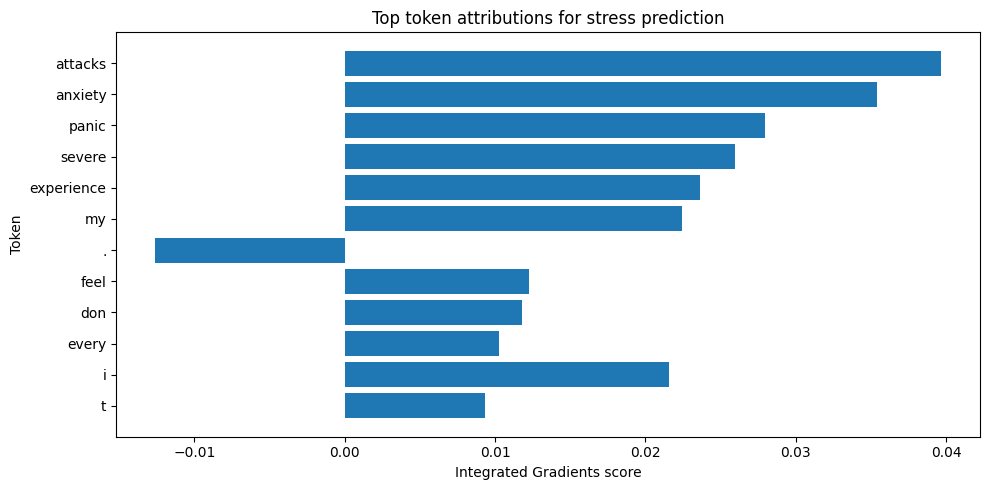

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Build a dataframe with token-level IG scores
ig_df = pd.DataFrame({
    "token": ig_tokens,
    "ig_score": ig_scores,
    "abs_score": np.abs(ig_scores)
})

# Show all tokens in original order
print("All token attributions (original order):")
display(ig_df[["token", "ig_score"]])

# Show most important tokens by absolute attribution
top_k = 15
ig_top = ig_df.sort_values("abs_score", ascending=False).head(top_k)

print(f"Top {top_k} tokens by |IG score|:")
display(ig_top[["token", "ig_score"]])

# Plot top tokens
plt.figure(figsize=(10, 5))
plt.barh(ig_top["token"][::-1], ig_top["ig_score"][::-1])
plt.xlabel("Integrated Gradients score")
plt.ylabel("Token")
plt.title("Top token attributions for stress prediction")
plt.tight_layout()
plt.show()

The Integrated Gradients analysis highlights several tokens that strongly support the **stress** prediction, including "attacks", "anxiety", "severe", "panic", and self-referential tokens such as "I" and "my". These are linguistically meaningful cues, because they reflect anxiety-related content, emotional intensity, and a strongly personal narrative style.

This result is qualitatively consistent with the SHAP analysis, which is encouraging because the two methods are based on different principles: SHAP is perturbation-based, whereas Integrated Gradients is gradient-based. The fact that both methods emphasize similar tokens suggests that the Transformer is relying on psychologically plausible signals rather than arbitrary artifacts.

The convergence delta is moderate rather than negligible, which suggests that the numerical approximation is acceptable for qualitative interpretation, but not perfectly tight. Therefore, I treat Integrated Gradients here as a useful interpretive signal rather than a highly precise quantitative attribution.

## 6. Summary

- Baseline explanations are transparent and global (feature coefficients).
- Transformer explanations are local and semantic (token-level attributions).
- Using both gives a balanced explainability view for the project: interpretability + expressive modeling.